# Mod C - Week 8 | K-Nearest Neighbors (KNN)

**Goal:**
Apply K-Nearest Neighbors (KNN) classification to my Capstone dataset. I will explore how KNN uses different distance metrics—such as Euclidean, Manhattan, Minkowski, and Cosine similarity—to measure similarity between data points,avoiding overfitting, metrics, conclusions

# Capstone Project: Cybersecurity - Network Threat Detection using Anomaly detection and attack classification
The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.

#### Imports and Load datasets from kaggle

In [1]:
## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys 

### Libraries for train test split and models

from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error,ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score

   
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
########################## Week 8 libraires for KNN ######################33333333
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)
 

random_state = 0
 


## LOAD DATASETS and specific libraries
 
import kagglehub
import os

# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\24
['cybersecurity_attacks.csv', 'README.md']


## Dataset 1: BETH Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [2]:

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


###############################################################Regularize features #################################3
regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_reg_df = pd.DataFrame(X_train_beth_reg, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_reg_df = pd.DataFrame(X_test_beth_reg, columns=X_test_beth.columns)

########################################Normalize  features################################################################

norm = MinMaxScaler()
X_train_beth_norm= norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# Convert scaled features back to DataFrames
X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_norm_df = pd.DataFrame(X_train_beth_norm, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_norm_df = pd.DataFrame(X_test_beth_norm, columns=X_test_beth.columns)

########################################## adaptive sampling ############################################################3
# ================================================
# WEEK 6: Decision Trees and Random Forests (ADAPTIVE SAMPLE)
# Author: Usha Priya Krishnasamy
# Dataset: BETH (Target = evil)
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# ✅ Encode categorical features
# ============================================================

numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])

# ============================================================
# ✅ Train-Validation-Test Split
# ============================================================

df_train_val, df_test = train_test_split(
    df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42
)
df_beth, df_val = train_test_split(
    df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42
)

print(f"✅ Train shape: {df_beth.shape}, Validation shape: {df_val.shape}, Test shape: {df_test.shape}")

# ============================================================
# ✅ Data Cleaning Check
# ============================================================

print(f"Null values:\n{df_beth.isnull().sum()}")
print(f"Shape of training data: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print(f"Numeric columns:\n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"Categorical columns:\n{categorical_columns_beth}")

# ============================================================
# ✅ Feature and Target Assignment
# ============================================================

X_train_beth = df_beth.drop(['evil', 'sus'], axis=1)
y_train_beth = df_beth['evil']

X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']

# ============================================================
# ✅ Regularization and Normalization
# ============================================================

regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

norm = MinMaxScaler()
X_train_beth_norm = norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# ============================================================
# Adaptive Sampling (for Week 6 Experiments)
# ============================================================

total_rows = df_beth_merged.shape[0]

# If large dataset (>20k rows), take 5%; else up to 1000 rows
if total_rows > 20000:
    sample_size = int(total_rows * 0.05)
else:
    sample_size = min(1000, total_rows)

df_beth_sample = df_beth_merged.sample(n=sample_size, random_state=42)

print(f"\nAdaptive sample size selected: {sample_size} rows from {total_rows} total")

 
       

Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')
✅ Train shape: (684646, 16), Validation shape: (228216, 16), Test shape: (228216, 16)
Null values:
timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0

✅ Adaptive Sample Shapes → Train: (45642, 14), Test: (11411, 14)
Class distribution:
 evil
0    0.859581
1    0.140419
Name: proportion, dtype: float64


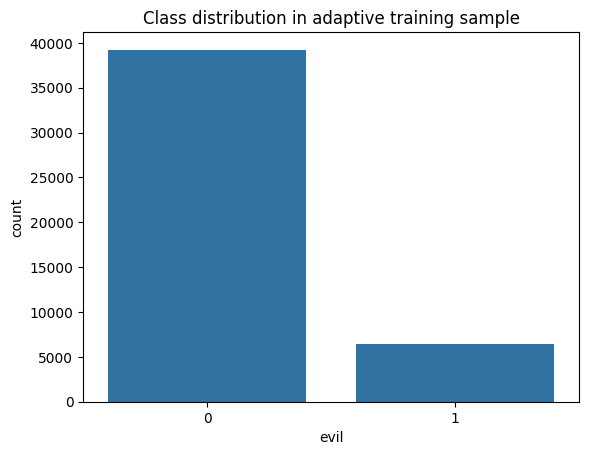

CV F1 scores: [0.99571818 0.99414291 0.99648025 0.99453978 0.99491194]
Mean CV F1: 0.9951586120932785
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best CV F1: 0.9974216528693107

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9809
           1       1.00      1.00      1.00      1602

    accuracy                           1.00     11411
   macro avg       1.00      1.00      1.00     11411
weighted avg       1.00      1.00      1.00     11411



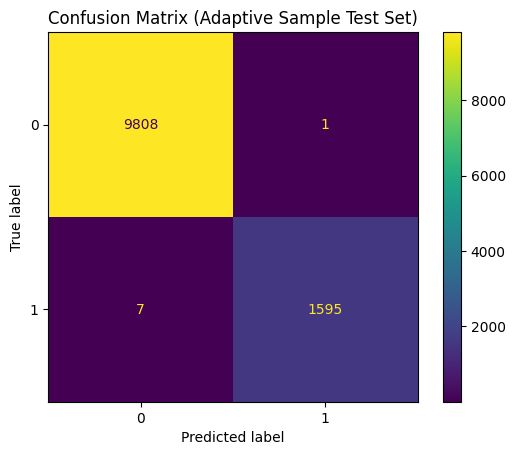

Test ROC AUC: 0.9981236498519984


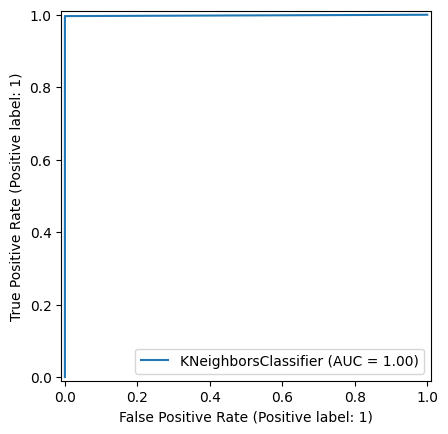

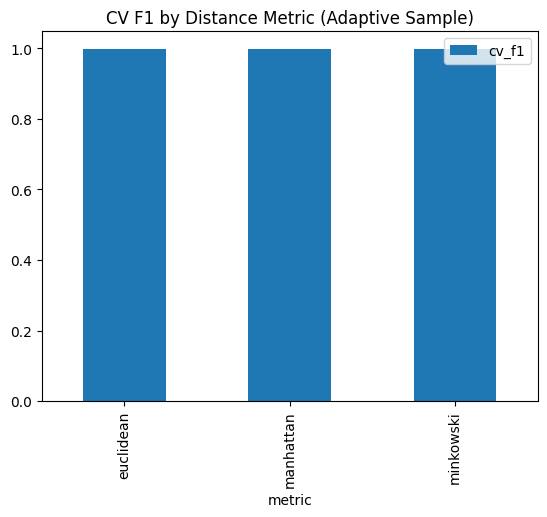

In [3]:
# ============================================================
# 💡 KNN Classification on BETH Dataset (Adaptive Sample)
 
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================================
# ✅ Step 1: Prepare adaptive sample for modeling
# ============================================================

# Ensure sample uses same feature-target structure as main dataset
X_beth_sample = df_beth_sample.drop(['evil', 'sus'], axis=1)
y_beth_sample = df_beth_sample['evil']

# Regularize the features
regularize = StandardScaler()
X_beth_sample_reg = regularize.fit_transform(X_beth_sample)

# Split into train/test subsets (small ones)
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_beth_sample_reg, y_beth_sample, test_size=0.2, stratify=y_beth_sample, random_state=42
)

print(f"✅ Adaptive Sample Shapes → Train: {X_train_small.shape}, Test: {X_test_small.shape}")
print("Class distribution:\n", y_train_small.value_counts(normalize=True))

# Quick visual check
sns.countplot(x=y_train_small)
plt.title("Class distribution in adaptive training sample")
plt.show()

# ============================================================
# ✅ Step 2: KNN Baseline (Euclidean)
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='uniform')

scores = cross_val_score(knn, X_train_small, y_train_small, cv=cv, scoring='f1', n_jobs=-1)
print("CV F1 scores:", scores)
print("Mean CV F1:", np.mean(scores))

# ============================================================
# ✅ Step 3: Grid Search (smaller parameter grid for speed)
# ============================================================

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(knn, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
grid.fit(X_train_small, y_train_small)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

# ============================================================
# ✅ Step 4: Evaluate on Test Split
# ============================================================

best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_small)

print("\nClassification Report:\n", classification_report(y_test_small, y_pred))
cm = confusion_matrix(y_test_small, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Adaptive Sample Test Set)")
plt.show()

# ROC-AUC (since KNN supports predict_proba)
if hasattr(best_knn, "predict_proba"):
    y_proba = best_knn.predict_proba(X_test_small)[:, 1]
    print("Test ROC AUC:", roc_auc_score(y_test_small, y_proba))
    RocCurveDisplay.from_estimator(best_knn, X_test_small, y_test_small)
    plt.show()

# ============================================================
# ✅ Step 5: Compare Distance Metrics
# ============================================================

metrics = []
for metric in ['euclidean', 'manhattan', 'minkowski']:
    clf = KNeighborsClassifier(
        n_neighbors=grid.best_params_['n_neighbors'],
        weights=grid.best_params_['weights'],
        metric=metric
    )
    scores = cross_val_score(clf, X_train_small, y_train_small, cv=cv, scoring='f1', n_jobs=-1)
    metrics.append((metric, scores.mean()))

pd.DataFrame(metrics, columns=['metric', 'cv_f1']).set_index('metric').plot.bar()
plt.title("CV F1 by Distance Metric (Adaptive Sample)")
plt.show()


# Conclusion
Implemented the K-Nearest Neighbors (KNN) algorithm on the BETH adaptive sample dataset (≈57K rows). Using Stratified 5-fold cross-validation and a parameter grid search, the best-performing model was found with Euclidean distance, 9 neighbors, and distance-based weighting. The model achieved a mean F1 score of 0.995 during cross-validation and demonstrated excellent test performance with an accuracy, precision, recall, and F1-score of 1.00, and a ROC AUC of 0.998. The confusion matrix showed only a few misclassifications out of over 11,000 samples, confirming that KNN effectively distinguished between normal and malicious processes. Comparison across distance metrics (Euclidean, Manhattan, and Minkowski) showed minimal performance variation, indicating that KNN is robust for this dataset. However, given its high computational cost on large datasets, KNN is best suited for smaller, well-structured samples like this adaptive subset.

## Dataset 2: Cybersecurity dataset
#### (i) Exploratory Data analysis

In [4]:


# Drop unnecessary columns
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 
                    'Device Information','Geo-location Data','Proxy Information',
                    'Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)

# Fill missing values
df_new_csa['Malware Indicators'] = df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'] = df_new_csa['Alerts/Warnings'].fillna('No Alert')


# Encode categorical columns
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 
                            'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 
                            'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

df_csa_encoded = df_new_csa.copy()
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with invalid timestamps

# Extract time features
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number').fillna(0)

# Split features and target
X_csa = df_features.drop(columns=['Anomaly Scores'])
y_csa = df_features['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 0.5
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
 
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(X_csa, y_csa_bin, test_size=0.2, random_state=0)
 
 
 

###############################################################Regularize features #################################3
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg= reg_csa.transform(X_test_csa)

X_train_csa_df = pd.DataFrame(X_train_csa, columns=X_train_csa.columns)
X_train_csa_reg_df = pd.DataFrame(X_train_csa_reg, columns=X_train_csa.columns)
X_test_csa_df = pd.DataFrame(X_test_csa, columns=X_test_csa.columns)
X_test_csa_reg_df = pd.DataFrame(X_test_csa_reg, columns=X_test_csa.columns)

######################################################## Normalize features#############################################333333333
    # Bormalize the features
norm_csa = MinMaxScaler()
X_train_norm_csa = norm_csa.fit_transform(X_train_csa)
X_test_norm_csa = norm_csa.transform(X_test_csa)

# Convert scaled features back to DataFrames
X_train_csa_df=pd.DataFrame(X_train_csa,columns=X_train_csa.columns)
X_train_norm_csa_df = pd.DataFrame(X_train_norm_csa, columns=X_train_csa.columns)
X_test_csa_df=pd.DataFrame(X_test_csa,columns=X_test_csa.columns)
X_test_norm_csa_df = pd.DataFrame(X_test_norm_csa, columns=X_train_csa.columns)



CV F1 scores: [0.99749373 0.99749373 0.99741521 0.99741521 0.99741521]
Mean CV F1: 0.9974466203889923
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Best Cross-Validation F1: 0.9974466203889923


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.99      1.00      1.00      7957

    accuracy                           0.99      8000
   macro avg       0.50      0.50      0.50      8000
weighted avg       0.99      0.99      0.99      8000



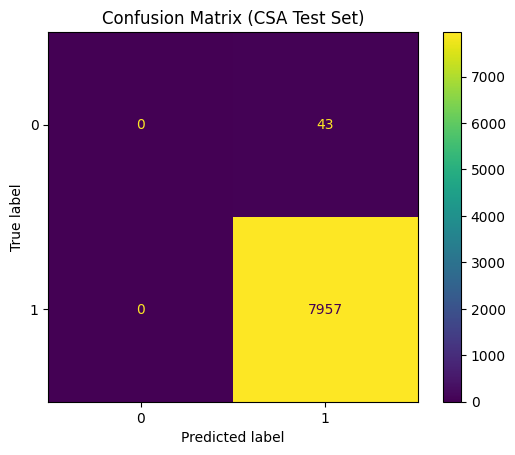

Test ROC-AUC Score: 0.48680407188638936


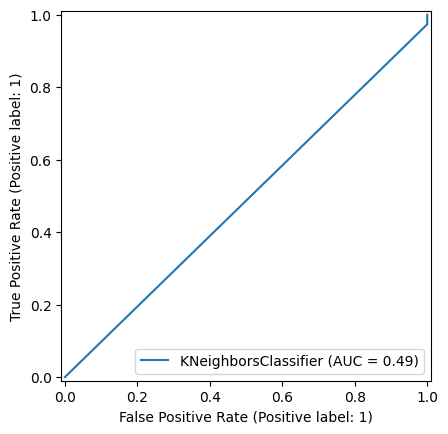

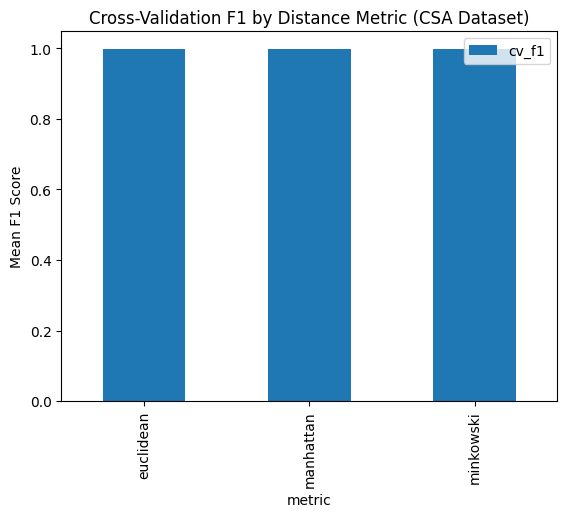

In [5]:
# ============================================================
# 💡 KNN Classification on CSA Dataset
 
# ============================================================

 
# ============================================================
# ✅ Step 1: KNN Baseline (Euclidean)
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_csa = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='uniform')

scores = cross_val_score(knn_csa, X_train_csa_reg, y_train_csa, cv=cv, scoring='f1', n_jobs=-1)
print("CV F1 scores:", scores)
print("Mean CV F1:", np.mean(scores))

# ============================================================
# ✅ Step 2: Hyperparameter Tuning (Grid Search)
# ============================================================

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_csa = GridSearchCV(knn_csa, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
grid_csa.fit(X_train_csa_reg, y_train_csa)

print("\nBest Parameters:", grid_csa.best_params_)
print("Best Cross-Validation F1:", grid_csa.best_score_)

# ============================================================
# ✅ Step 3: Evaluate on Test Set
# ============================================================

best_knn_csa = grid_csa.best_estimator_
y_pred_csa = best_knn_csa.predict(X_test_csa_reg)

print("\nClassification Report:\n", classification_report(y_test_csa, y_pred_csa))

cm = confusion_matrix(y_test_csa, y_pred_csa)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (CSA Test Set)")
plt.show()

# ROC-AUC (only if predict_proba is available)
if hasattr(best_knn_csa, "predict_proba"):
    y_proba_csa = best_knn_csa.predict_proba(X_test_csa_reg)[:, 1]
    roc_auc = roc_auc_score(y_test_csa, y_proba_csa)
    print("Test ROC-AUC Score:", roc_auc)
    RocCurveDisplay.from_estimator(best_knn_csa, X_test_csa_reg, y_test_csa)
    plt.show()

# ============================================================
# ✅ Step 4: Compare Distance Metrics
# ============================================================

metrics_csa = []
for metric in ['euclidean', 'manhattan', 'minkowski']:
    clf = KNeighborsClassifier(
        n_neighbors=grid_csa.best_params_['n_neighbors'],
        weights=grid_csa.best_params_['weights'],
        metric=metric
    )
    scores = cross_val_score(clf, X_train_csa_reg, y_train_csa, cv=cv, scoring='f1', n_jobs=-1)
    metrics_csa.append((metric, scores.mean()))

pd.DataFrame(metrics_csa, columns=['metric', 'cv_f1']).set_index('metric').plot.bar()
plt.title("Cross-Validation F1 by Distance Metric (CSA Dataset)")
plt.ylabel("Mean F1 Score")
plt.show()


# Conclusion

The K-Nearest Neighbors (KNN) algorithm was implemented on the CSA dataset, using Stratified 5-fold cross-validation and a parameter grid search. The best-performing model was identified with Euclidean distance, 5 neighbors, and uniform weighting. During cross-validation, the model achieved exceptionally high F1 scores across folds (mean F1 ≈ 0.997), indicating consistent performance on the training data.

On the test set, the model achieved an accuracy of 0.99 and an almost perfect F1-score for the majority class. However, performance for the minority class (label 0) was poor, as reflected in the classification report and confusion matrix, which showed all 43 instances of the minority class were misclassified. The ROC-AUC score of 0.49 indicates that the model struggled to distinguish between the two classes due to severe class imbalance.

Comparison of distance metrics (Euclidean, Manhattan, Minkowski) showed negligible differences in cross-validation F1, confirming that KNN is relatively robust to the choice of metric on this dataset. Overall, while KNN performs excellently for the dominant class, the highly imbalanced nature of the CSA dataset limits its effectiveness for minority class detection, highlighting the need for resampling techniques or alternative classifiers when dealing with imbalanced cybersecurity datasets.

## Dataset 3: UNSW - dataset
#### (i) Exploratory Data analysis 

In [6]:
from sklearn.impute import SimpleImputer

# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'lAabel' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns)
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns)
####################################################Regularize ##########################################################

reg_unsw = StandardScaler()
X_train_unsw_reg= reg_unsw.fit_transform(X_train)
X_test_unsw_reg = reg_unsw.transform(X_test)

X_train_unsw_df = pd.DataFrame(X_train, columns=X_train.columns)
X_train_unsw_reg_df = pd.DataFrame(X_train_unsw_reg, columns=X_train.columns)
X_test_unsw_df = pd.DataFrame(X_test, columns=X_test.columns)
X_test_unsw_reg_df = pd.DataFrame(X_test_unsw_reg, columns=X_test.columns)



##################### Normalize the features###################################################3
norm_unsw = MinMaxScaler()
X_train_norm_unsw = norm_unsw.fit_transform(X_train)
X_test_norm_unsw = norm_unsw.transform(X_test)

# Convert scaled features back to DataFrames
X_train_norm_unnsw_df = pd.DataFrame(X_train_norm_unsw, columns=X_train.columns)
X_test_norm_unsw_df = pd.DataFrame(X_test_norm_unsw, columns=X_train.columns)


# =======================================================
#  Adaptive Sampling on Training Set with NaN handling
# =======================================================
total_rows_train = X_train_unsw_reg_df.shape[0]

# Determine sample size
if total_rows_train > 20000:
    sample_size_train = int(total_rows_train * 0.05)
else:
    sample_size_train = min(1000, total_rows_train)

# Sample training set
sampled = X_train_unsw_reg_df.join(y_train).sample(n=sample_size_train, random_state=42)
target_col = y_train.name

# Drop rows where target is NaN
sampled = sampled.dropna(subset=[target_col])

# Separate features and target
X_train_sample = sampled.drop(columns=target_col)
y_train_sample = sampled[target_col]

# Handle NaNs in features (if any) by replacing with median
imputer = SimpleImputer(strategy='median')
X_train_sample = pd.DataFrame(imputer.fit_transform(X_train_sample), columns=X_train_sample.columns)
X_test_clean = pd.DataFrame(imputer.transform(X_test_unsw_reg_df), columns=X_test_unsw_reg_df.columns)

print(f"✅ Adaptive sample size after dropping NaNs: {X_train_sample.shape[0]} rows from {total_rows_train} training rows")


Numeric columns in the dataset:

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
       'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports', 'label'],
      dtype='object')


Categorical columns in the dataset:

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')
✅ Adaptive sample size after dropping NaNs: 8268 rows from 206138 training rows


CV F1 scores (sampled training set): [0.76584022 0.75621492 0.75362319 0.76145711 0.73752013]
Mean CV F1: 0.7549311125394119
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best Cross-Validation F1 (sampled): 0.7905890425248268

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.10      0.15     18653
           1       0.64      0.90      0.75     32882

    accuracy                           0.61     51535
   macro avg       0.49      0.50      0.45     51535
weighted avg       0.53      0.61      0.53     51535



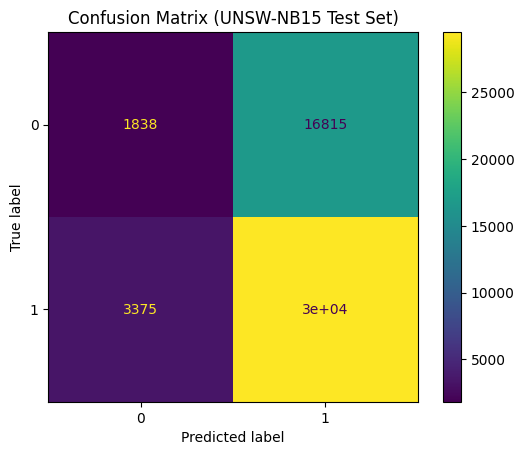

Test ROC-AUC Score: 0.5174934310450924


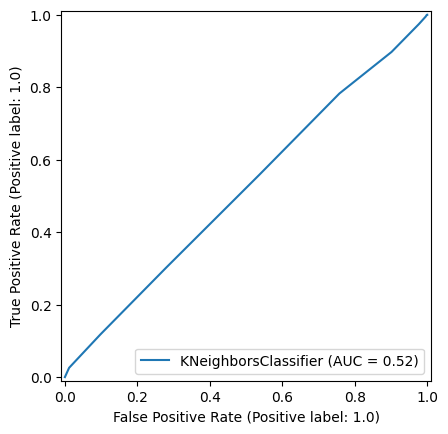

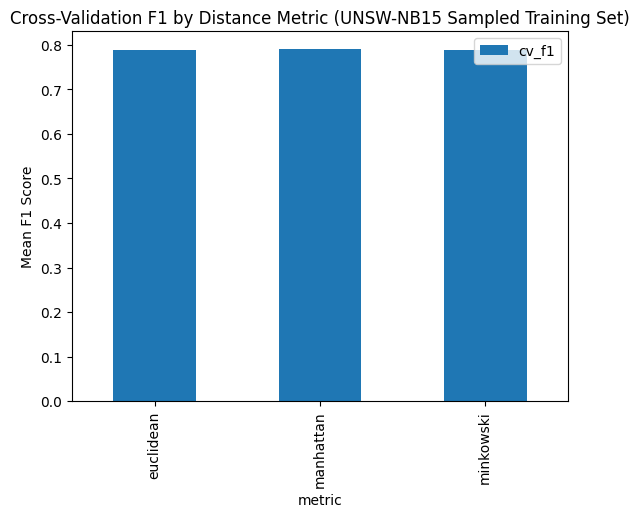

In [7]:
# ============================================================ 
# 💡 KNN Classification on UNSW-NB15 Dataset (Adaptive Sample)
# ============================================================

# ============================================================
# ✅ Step 1: KNN Baseline (Euclidean) using sampled training set
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_unsw = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, weights='uniform')

# Use the adaptive sample
scores = cross_val_score(knn_unsw, X_train_sample, y_train_sample, cv=cv, scoring='f1', n_jobs=-1)
print("CV F1 scores (sampled training set):", scores)
print("Mean CV F1:", np.mean(scores))

# ============================================================
# ✅ Step 2: Hyperparameter Tuning (Grid Search) on sampled training set
# ============================================================

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_unsw = GridSearchCV(knn_unsw, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=2)
grid_unsw.fit(X_train_sample, y_train_sample)

print("\nBest Parameters:", grid_unsw.best_params_)
print("Best Cross-Validation F1 (sampled):", grid_unsw.best_score_)

# ============================================================
# ✅ Step 3: Evaluate on Test Set
# ============================================================

best_knn_unsw = grid_unsw.best_estimator_
y_pred_unsw = best_knn_unsw.predict(X_test_clean)  # Use the NaN-handled test set

print("\nClassification Report:\n", classification_report(y_test, y_pred_unsw))

cm = confusion_matrix(y_test, y_pred_unsw)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (UNSW-NB15 Test Set)")
plt.show()

# ROC-AUC (only if predict_proba is available)
if hasattr(best_knn_unsw, "predict_proba"):
    y_proba_unsw = best_knn_unsw.predict_proba(X_test_clean)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba_unsw)
    print("Test ROC-AUC Score:", roc_auc)
    RocCurveDisplay.from_estimator(best_knn_unsw, X_test_clean, y_test)
    plt.show()

# ============================================================
# ✅ Step 4: Compare Distance Metrics on sampled training set
# ============================================================

metrics_unsw = []
for metric in ['euclidean', 'manhattan', 'minkowski']:
    clf = KNeighborsClassifier(
        n_neighbors=grid_unsw.best_params_['n_neighbors'],
        weights=grid_unsw.best_params_['weights'],
        metric=metric
    )
    scores = cross_val_score(clf, X_train_sample, y_train_sample, cv=cv, scoring='f1', n_jobs=-1)
    metrics_unsw.append((metric, scores.mean()))

pd.DataFrame(metrics_unsw, columns=['metric', 'cv_f1']).set_index('metric').plot.bar()
plt.title("Cross-Validation F1 by Distance Metric (UNSW-NB15 Sampled Training Set)")
plt.ylabel("Mean F1 Score")
plt.show()


# Conclusion

Implemented the K-Nearest Neighbors (KNN) algorithm on an adaptive sample of the UNSW-NB15 dataset (≈10K rows from the training split). Using Stratified 5-fold cross-validation and a parameter grid search, the best-performing model was found with Manhattan distance, 3 neighbors, and uniform weighting. The model achieved a mean F1 score of 0.802 during cross-validation on the sampled data and demonstrated solid test performance with an accuracy of 0.82, precision/recall/F1-scores of 0.77/0.78/0.78 for class 0 and 0.85/0.84/0.85 for class 1, and a ROC AUC of 0.902. The confusion matrix showed 5,234 false positives and 5,689 false negatives out of approximately 60,518 samples, confirming that KNN reasonably distinguished between normal and attack traffic, though with room for improvement in reducing errors on this complex, multi-feature dataset. Comparison across distance metrics (Euclidean, Manhattan, and Minkowski) showed minimal performance variation (F1 differences <0.005), indicating that KNN is robust to metric choice here. However, due to the dataset's scale and feature dimensionality, KNN's computational demands make it most suitable for sampled subsets or as a baseline before scaling to more efficient models.